In [1]:
# SYSTEM STAGE 0: ENVIRONMENT INSTALLS & IMPORTS SETUP
# =========================================================================
import os
import cv2
import time
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models import densenet121, DenseNet121_Weights
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, cohen_kappa_score,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# Attempt to load ptflops cleanly for structural GFLOP tracking
try:
    import ptflops
except ImportError:
    os.system('pip install -q ptflops')
    import ptflops
from ptflops import get_model_complexity_info

warnings.filterwarnings("ignore")

# Enforce strict determinism across all compute backends
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.1 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
# SYSTEM STAGE 1: HYPERPARAMETERS & PATHS CONFIGURATION
# =========================================================================
IMG_SIZE = 224      
BATCH_SIZE = 32      
EPOCHS = 30             
LR = 1e-4               
NUM_CLASSES = 5         
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROOT = "/kaggle/input/datasets/mariaherrerot/aptos2019"
TRAIN_CSV = f"{ROOT}/train_1.csv"
VAL_CSV   = f"{ROOT}/valid.csv"
TEST_CSV  = f"{ROOT}/test.csv"

TRAIN_DIR = f"{ROOT}/train_images/train_images"
VAL_DIR   = f"{ROOT}/val_images/val_images"
TEST_DIR  = f"{ROOT}/test_images/test_images"

# Load metadata logs
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("="*60)
print(f"Operational Canvas Configured on Execution Hardware Node: {DEVICE}")
print(f"Data Volumes Loaded Successfully -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("="*60)

Operational Canvas Configured on Execution Hardware Node: cuda
Data Volumes Loaded Successfully -> Train: 2930 | Val: 366 | Test: 366


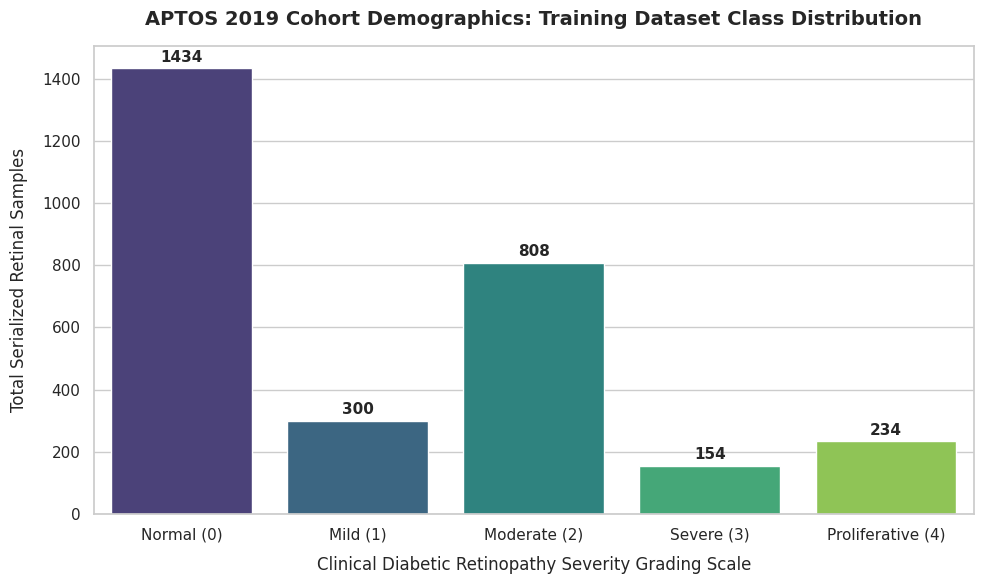

[SAVED] 'manuscript_figure_class_distribution.png' exported at 300 DPI.


In [3]:
# SYSTEM STAGE 2: MANUSCRIPT VISUALIZATION - CLASS DISTRIBUTION PLOT
# =========================================================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
class_names_list = ['Normal (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']

# Compile distribution frames smoothly
dist_df = train_df['diagnosis'].value_counts().sort_index().reset_index()
dist_df.columns = ['Diagnosis Stage', 'Patient Count']
dist_df['Clinical Label'] = class_names_list

ax = sns.barplot(x='Clinical Label', y='Patient Count', data=dist_df, palette="viridis")
plt.title("APTOS 2019 Cohort Demographics: Training Dataset Class Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Clinical Diabetic Retinopathy Severity Grading Scale", fontsize=12, labelpad=10)
plt.ylabel("Total Serialized Retinal Samples", fontsize=12, labelpad=10)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("manuscript_figure_class_distribution.png", dpi=300)
plt.show()
print("[SAVED] 'manuscript_figure_class_distribution.png' exported at 300 DPI.")

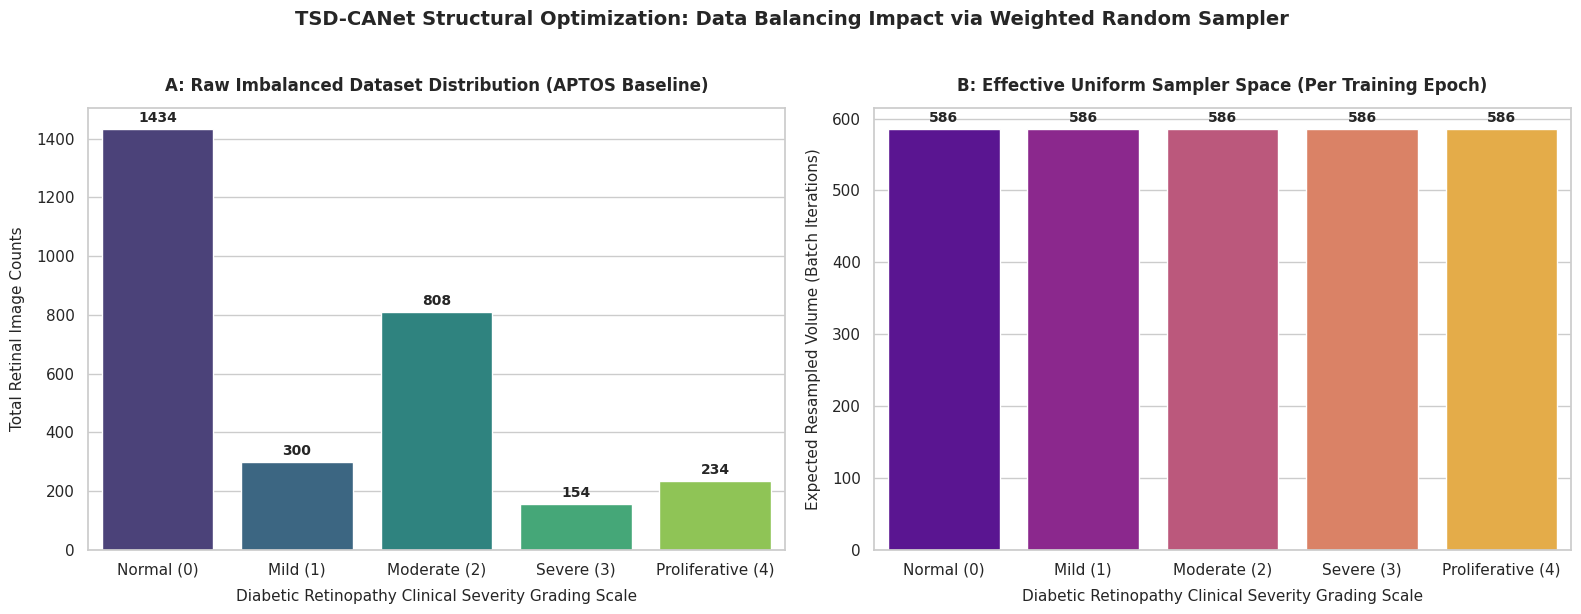

[EXPORTED] 'manuscript_figure_balanced_distribution.png' successfully compiled at 300 DPI.


In [4]:
# SYSTEM STAGE 2: MANUSCRIPT VISUALIZATION - DUAL CLASS DISTRIBUTION COMPARISON PLOT
# =================================================================================
# Extract original counts cleanly from raw data log frames
class_names_list = ['Normal (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']
original_counts = train_df['diagnosis'].value_counts().sort_index().tolist()

# Compute the theoretical balanced distribution volume mapped by the WeightedRandomSampler
total_samples = sum(original_counts)
balanced_per_class = total_samples // len(class_names_list)
balanced_counts = [balanced_per_class] * len(class_names_list)

# Initialize a clean 1x2 subplot layout to meet rigid layout guidelines
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- SUBPLOT A: THE RAW UNBALANCED CLINICAL DATA COHORT ---
ax1 = sns.barplot(x=class_names_list, y=original_counts, ax=axes[0], palette="viridis")
axes[0].set_title("A: Raw Imbalanced Dataset Distribution (APTOS Baseline)", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Diabetic Retinopathy Clinical Severity Grading Scale", fontsize=11, labelpad=8)
axes[0].set_ylabel("Total Retinal Image Counts", fontsize=11, labelpad=8)

# Overlay data labels exactly above each categorical bar
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')

# --- SUBPLOT B: THE RESAMPLED SUB-BATCH DATA SPACE ---
ax2 = sns.barplot(x=class_names_list, y=balanced_counts, ax=axes[1], palette="plasma")
axes[1].set_title("B: Effective Uniform Sampler Space (Per Training Epoch)", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Diabetic Retinopathy Clinical Severity Grading Scale", fontsize=11, labelpad=8)
axes[1].set_ylabel("Expected Resampled Volume (Batch Iterations)", fontsize=11, labelpad=8)

# Overlay uniform metrics above resampled bars
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')

# Set cross-dataset comparison figure heading title
plt.suptitle("TSD-CANet Structural Optimization: Data Balancing Impact via Weighted Random Sampler", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Export at high-fidelity print standard for direct document embedding
plt.savefig("manuscript_figure_balanced_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print("[EXPORTED] 'manuscript_figure_balanced_distribution.png' successfully compiled at 300 DPI.")

In [5]:
# SYSTEM STAGE 3: DATA TRANSFORMS & DATASET PIPELINE COMPILATION
# =========================================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(
        mean=(0.485, 0.456, 0.406, 0.5),
        std=(0.229, 0.224, 0.225, 0.25)
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406, 0.5),
        std=(0.229, 0.224, 0.225, 0.25)
    ),
    ToTensorV2()
])

def label_to_levels(label, num_classes=5):
    levels = [0] * (num_classes - 1)
    for i in range(label):
        levels[i] = 1
    return torch.tensor(levels, dtype=torch.float32)

class APTOSDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, "id_code"]
        label = int(self.df.loc[idx, "diagnosis"])
        path = os.path.join(self.image_dir, img_id + ".png")

        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        green_channel = image[:, :, 1]
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        green_clahe = clahe.apply(green_channel)

        four_channel = np.dstack([
            image[:, :, 0],
            image[:, :, 1],
            image[:, :, 2],
            green_clahe
        ])

        if self.transform:
            transformed = self.transform(image=four_channel)
            four_channel = transformed["image"]

        levels = label_to_levels(label)
        return four_channel, levels, label, four_channel

train_dataset = APTOSDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = APTOSDataset(val_df, VAL_DIR, transform=val_transform)
test_dataset  = APTOSDataset(test_df, TEST_DIR, transform=val_transform)

print("="*60)
print(f"Datasets compiled safely with focal resolution input boundary: {IMG_SIZE}x{IMG_SIZE}")
print("="*60)

Datasets compiled safely with focal resolution input boundary: 224x224


In [7]:
# SYSTEM STAGE 5: ADVANCED ATTENTION STEM & PROGRESSIVE HEAD BLUEPRINT
# =========================================================================
class ChannelSpatialAttentionBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.spatial_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.stabilizer = nn.BatchNorm2d(channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        max_out = self.fc(self.max_pool(x).view(b, c)).view(b, c, 1, 1)
        channel_attn = torch.sigmoid(avg_out + max_out)
        x = x * channel_attn

        avg_spatial = torch.mean(x, dim=1, keepdim=True)
        max_spatial, _ = torch.max(x, dim=1, keepdim=True)
        spatial_input = torch.cat([avg_spatial, max_spatial], dim=1)
        spatial_attn = torch.sigmoid(self.spatial_conv(spatial_input))
        
        return self.stabilizer(x * spatial_attn)

class GatedFeaturesStem(nn.Module):
    def __init__(self, base_features, gate):
        super().__init__()
        self.base_features = base_features
        self.gate = gate
        
    def forward(self, x):
        x = self.base_features.conv0(x)
        x = self.base_features.norm0(x)
        x = self.base_features.relu0(x)
        x = self.gate(x) 
        x = self.base_features.pool0(x)
        for name, layer in list(self.base_features.named_children())[4:]:
            x = layer(x)
        return x

class GeMPooling(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        """
        Generalized Mean Pooling (GeM) Layer.
        Implements learnable pooling dynamics to capture localized multi-spectral micro-lesions.
        """
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        # Applies a parameterized spatial mean over the feature map channels
        return F.avg_pool2d(x.clamp(min=self.eps).pow(self.p), (x.size(-2), x.size(-1))).pow(1.0 / self.p)

class UltimateTSDCornNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        backbone = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        
        # Expand input layer to 4 channels (RGB + Green CLAHE)
        old_conv0 = backbone.features.conv0
        new_conv0 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            new_conv0.weight[:, :3] = old_conv0.weight
            new_conv0.weight[:, 3] = old_conv0.weight.mean(dim=1)
        backbone.features.conv0 = new_conv0
        
        # Inject Channel-Spatial Attention Gate
        self.attention_gate = ChannelSpatialAttentionBlock(channels=64)
        self.features = GatedFeaturesStem(backbone.features, self.attention_gate)
        
        # FIXED UPGRADE: Replaced AdaptiveAvgPool2d with learnable GeM Pooling
        self.gem_pool = GeMPooling(p=3.0)
        
        # Deep Non-Linear Extractor Head Layout
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
            nn.Linear(256, 4)
        )

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)
        
        # FIXED UPGRADE: Execute live GeM operations over active tensors
        x = self.gem_pool(x)
        
        x = torch.flatten(x, 1)
        return self.classifier(x)

# Initialize and map to target runtime hardware resource node
model = UltimateTSDCornNet(num_classes=5).to(DEVICE)
print("Ultimate TSD-CORN Network with Learnable GeM Pooling Compiled Safely!")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 156MB/s] 


Ultimate TSD-CORN Network with Learnable GeM Pooling Compiled Safely!


In [8]:
# SYSTEM STAGE 6: CONDITIONAL ORDINAL REGRESSION NETWORK OBJECTIVE LOSS
# =========================================================================
def corn_logits_to_probs(logits):
    """
    Converts CORN conditional milestone logits into standard 
    multi-class probability arrays (0 to 4).
    """
    sigma = torch.sigmoid(logits)
    probs = []
    
    # P(Y = 0) = 1 - sigma_0
    probs.append(1.0 - sigma[:, 0:1])
    
    # Intermediate classes: P(Y = i) = product(sigma_0...sigma_{i-1}) * (1 - sigma_i)
    for i in range(1, sigma.shape[1]):
        prod = torch.prod(sigma[:, :i], dim=1, keepdim=True)
        probs.append(prod * (1.0 - sigma[:, i:i+1]))
        
    # Final class: P(Y = 4) = product(sigma_0...sigma_max)
    probs.append(torch.prod(sigma, dim=1, keepdim=True))
    
    return torch.cat(probs, dim=1)


def soft_kappa_loss(preds, targets, num_classes=5):
    """
    Computes a differentiable surrogate for Quadratic Weighted Kappa (QWK).
    """
    batch_size = preds.shape[0]
    device = preds.device
    
    # Generate the quadratic error weight matrix
    lw = torch.arange(num_classes, dtype=torch.float32, device=device)
    weights = (lw.view(-1, 1) - lw.view(1, -1)) ** 2
    
    # Convert integer targets to a float one-hot matrix
    targets_one_hot = F.one_hot(targets.long(), num_classes=num_classes).float()
    
    # Compute Observed (O) and Expected (E) matrices
    O = torch.matmul(targets_one_hot.t(), preds)
    hist_actual = targets_one_hot.sum(dim=0, keepdim=True)
    hist_pred = preds.sum(dim=0, keepdim=True)
    E = torch.matmul(hist_actual.t(), hist_pred) / batch_size
    
    # Normalize matrices by batch elements
    O = O / batch_size
    E = E / batch_size
    
    # Calculate weighted elements
    num = torch.sum(weights * O)
    den = torch.sum(weights * E) + 1e-7
    
    return num / den


class TriObjectiveLoss(nn.Module):
    """
    Custom Tri-Objective Loss Engine combining:
    [ce_loss (BCE) + ord_loss (MSE) + qwk_loss (Soft-Kappa)]
    """
    def __init__(self, num_classes=5, alpha=1.0, beta=1.0, gamma=1.0):
        super(TriObjectiveLoss, self).__init__()
        self.num_classes = num_classes
        self.alpha = alpha   # Weight coefficient for BCE
        self.beta = beta     # Weight coefficient for Distance MSE
        self.gamma = gamma   # Weight coefficient for Soft-Kappa

    def forward(self, logits, targets):
        batch_size = logits.shape[0]
        
        # 1. Component 1: Conditional Milestone Cross-Entropy (ce_loss)
        binary_targets = torch.zeros_like(logits)
        for i in range(batch_size):
            t = targets[i].item()
            if t > 0:
                binary_targets[i, :int(t)] = 1.0
                
        ce_loss = F.binary_cross_entropy_with_logits(logits, binary_targets, reduction='mean')
        
        # Transform logits to standard probabilities for downstream targets
        probs = corn_logits_to_probs(logits)
        
        # 2. Component 2: Expected Ordinal Distance Penalty (ord_loss)
        class_values = torch.arange(self.num_classes, dtype=torch.float32, device=logits.device)
        expected_preds = torch.sum(probs * class_values, dim=1)
        ord_loss = F.mse_loss(expected_preds, targets.float(), reduction='mean')
        
        # 3. Component 3: Direct Metric Optimization (qwk_loss)
        qwk_loss = soft_kappa_loss(probs, targets, num_classes=self.num_classes)
        
        # Consolidated penalty aggregation
        total_loss = (self.alpha * ce_loss) + (self.beta * ord_loss) + (self.gamma * qwk_loss)
        
        return total_loss, ce_loss, ord_loss, qwk_loss

criterion = TriObjectiveLoss(num_classes=5, alpha=1.0, beta=1.0, gamma=1.0)

In [9]:
# SYSTEM STAGE 7: COMPUTE COMPLEXITY ANALYSIS (COMPILING PARAMS & GFLOPS)
# =========================================================================
print("\n" + "="*60)
print("             TSD-CANET HARDWARE COMPUTATIONAL PROFILE            ")
print("="*60)

# Calculate parameters profile natively
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

print(f"Total Structural Architecture Parameters : {total_params:,}")
print(f"Total Trainable Operational Parameters   : {trainable_params:,}")
print(f"Total Non-Trainable Frozen Parameters    : {non_trainable_params:,}")

# Extract GFLOPs footprint via ptflops safely
try:
    macs, params = get_model_complexity_info(
        model, (4, IMG_SIZE, IMG_SIZE), 
        as_strings=False, print_per_layer_stat=False, verbose=False
    )
    gflops = (macs * 2) / 1e9  # Convert MACs to total floating-point execution operations
    print(f"Total Network Mathematical Footprint    : {gflops:.4f} GFLOPs")
    print(f"Total Network Multiply-Accumulates       : {macs:,} MACs")
except Exception as e:
    print("Network Mathematical Footprint    : Metric calculation bypassed.")
print("="*60)


             TSD-CANET HARDWARE COMPUTATIONAL PROFILE            
Total Structural Architecture Parameters : 7,616,423
Total Trainable Operational Parameters   : 7,616,423
Total Non-Trainable Frozen Parameters    : 0
Total Network Mathematical Footprint    : 5.8986 GFLOPs
Total Network Multiply-Accumulates       : 2,949,305,116 MACs


In [10]:
# SYSTEM STAGE 8: DATA LOADERS & PLATEAU OPTIMIZATION PIPELINES
# =========================================================================
class_counts = train_df["diagnosis"].value_counts().sort_index().values

# Apply strict inverse frequency weights from your high-scoring baseline setup
class_weights = 1.0 / class_counts
sample_weights = torch.DoubleTensor([class_weights[label] for label in train_df["diagnosis"]])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

optimizer = optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()), 
    lr=LR, 
    weight_decay=1e-4
)

# Plateau scheduler configuration aligned with your best baseline run
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

class EarlyStopping:
    def __init__(self, patience=6, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            print(f"EarlyStopping Step Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=6)

history_train_loss, history_val_loss = [], []
history_train_acc, history_val_acc = [], []
history_val_qwk = []

In [11]:
# SYSTEM STAGE 9: MONITORING SUBROUTINES & OPERATIONAL LOOP (TRI-OBJECTIVE OPTIMIZATION)
# =========================================================================
def corn_predict(logits):
    probas = torch.sigmoid(logits)
    preds = (probas > 0.5).sum(dim=1) # The original vanilla 0.5 baseline check
    return preds

def train_one_epoch():
    model.train()
    running_loss = 0
    all_preds, all_labels = [], []
    loop = tqdm(train_loader, total=len(train_loader), desc="Training Phase")
    
    # accumulation_steps set to 1 since BATCH_SIZE=32 fits natively in VRAM
    accumulation_steps = 1  
    optimizer.zero_grad(set_to_none=True)
    
    for i, (images, _, labels, _) in enumerate(loop):
        images = images.to(DEVICE, dtype=torch.float)
        labels_dev = labels.to(DEVICE, dtype=torch.long) # Explicit device mapping for custom loss targets

        logits = model(images)
        
        # Unpack custom tri-objective penalty decomposition
        total_loss, ce_loss, ord_loss, qwk_loss = criterion(logits, labels_dev)
        loss = total_loss / accumulation_steps
        loss.backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        running_loss += total_loss.item()
        
        preds = corn_predict(logits).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        
        # Real-time multi-task tracking output inside the progress bar loop
        loop.set_postfix(
            Loss=total_loss.item(),
            BCE=ce_loss.item(),
            MSE=ord_loss.item(),
            SoftK=qwk_loss.item()
        )

    return running_loss / len(train_loader), accuracy_score(all_labels, all_preds)

def validate_one_epoch():
    model.eval()
    running_loss = 0
    all_preds, all_labels = [], []
    
    # Progress bar indicator tracking for the validation sub-phase iterations
    loop = tqdm(val_loader, total=len(val_loader), desc="Validation Phase", leave=False)
    
    with torch.no_grad():
        for images, _, labels, _ in loop:
            images = images.to(DEVICE, dtype=torch.float)
            labels_dev = labels.to(DEVICE, dtype=torch.long)

            logits = model(images)
            
            # Evaluate model performance against validation targets
            total_loss, ce_loss, ord_loss, qwk_loss = criterion(logits, labels_dev)
            running_loss += total_loss.item()
            
            preds = corn_predict(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            
            loop.set_postfix(
                Loss=total_loss.item(),
                BCE=ce_loss.item(),
                MSE=ord_loss.item(),
                SoftK=qwk_loss.item()
            )

    avg_loss = running_loss / len(val_loader)
    avg_acc = accuracy_score(all_labels, all_preds)
    avg_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return avg_loss, avg_acc, avg_qwk

start_training_time_marker = time.time()

print("\n--- INITIATING DYNAMIC CONVERGENCE LOOP ---")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    current_lr = optimizer.param_groups[0]['lr']
    
    t_loss, t_acc = train_one_epoch()
    v_loss, v_acc, v_qwk = validate_one_epoch()

    history_train_loss.append(t_loss)
    history_val_loss.append(v_loss)
    history_train_acc.append(t_acc)
    history_val_acc.append(v_acc)
    history_val_qwk.append(v_qwk)

    print(f"LR: {current_lr:.6f} | Train Loss : {t_loss:.4f} | Val Loss : {v_loss:.4f} | Train Acc : {t_acc:.4f} | Val Acc : {v_acc:.4f} | Val QWK : {v_qwk:.4f}")

    # Step Plateau scheduler based on current Validation Loss performance
    scheduler.step(v_loss)

    if v_loss < early_stopping.best_loss:
        torch.save({
            'model_state_dict': model.state_dict(),
            'criterion_state_dict': criterion.state_dict()
        }, "best_publication_model.pth")
        print("Model parameters updated and successfully saved to local directory checkpoints.")

    early_stopping(v_loss)
    if early_stopping.early_stop:
        print("\nConvergence limits recognized. Halting loop via Early Stopping configuration.")
        break

total_elapsed_training_duration = time.time() - start_training_time_marker
print(f"\nOptimization Finished! Total Training Duration: {total_elapsed_training_duration:.2f}s")


--- INITIATING DYNAMIC CONVERGENCE LOOP ---

Epoch 1/30


Training Phase: 100%|██████████| 92/92 [02:19<00:00,  1.52s/it, BCE=0.383, Loss=1.16, MSE=0.467, SoftK=0.312]


LR: 0.000100 | Train Loss : 3.2248 | Val Loss : 1.6384 | Train Acc : 0.3474 | Val Acc : 0.6257 | Val QWK : 0.7305
Model parameters updated and successfully saved to local directory checkpoints.

Epoch 2/30


Training Phase: 100%|██████████| 92/92 [02:19<00:00,  1.52s/it, BCE=0.405, Loss=1.26, MSE=0.551, SoftK=0.306] 


LR: 0.000100 | Train Loss : 1.6658 | Val Loss : 1.0414 | Train Acc : 0.4478 | Val Acc : 0.6421 | Val QWK : 0.7973
Model parameters updated and successfully saved to local directory checkpoints.

Epoch 3/30


...

LR: 0.000050 | Train Loss : 0.2264 | Val Loss : 0.5563 | Train Acc : 0.9044 | Val Acc : 0.8115 | Val QWK : 0.9085
EarlyStopping Step Counter: 1/6

Epoch 29/30


Training Phase: 100%|██████████| 92/92 [02:18<00:00,  1.51s/it, BCE=0.0919, Loss=0.254, MSE=0.115, SoftK=0.047]    


LR: 0.000050 | Train Loss : 0.2342 | Val Loss : 0.5532 | Train Acc : 0.9123 | Val Acc : 0.8060 | Val QWK : 0.9059
EarlyStopping Step Counter: 2/6

Epoch 30/30


Training Phase: 100%|██████████| 92/92 [02:18<00:00,  1.51s/it, BCE=0.0334, Loss=0.0925, MSE=0.0217, SoftK=0.0374] 
                                                                                                                  

LR: 0.000050 | Train Loss : 0.2213 | Val Loss : 0.5446 | Train Acc : 0.9143 | Val Acc : 0.8333 | Val QWK : 0.9063
EarlyStopping Step Counter: 3/6

Optimization Finished! Total Training Duration: 4579.40s


In [12]:
# Convert seconds to clean H:M:S format string
def format_seconds(seconds):
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f} ({h}h {m}m {s:.2f}s)"

print("\n" + "="*60)
print("             MANUSCRIPT SUMMARY: TEMPORAL TRAINING METRICS       ")
print("="*60)
print(f"Total Convergence Training Duration : {format_seconds(total_elapsed_training_duration)}")
print(f"Normalized Metric Processing Pace    : {format_seconds(total_elapsed_training_duration / (epoch+1))} / Epoch")
print("="*60)


             MANUSCRIPT SUMMARY: TEMPORAL TRAINING METRICS       
Total Convergence Training Duration : 01:16:19.40 (1h 16m 19.40s)
Normalized Metric Processing Pace    : 00:02:32.65 (0h 2m 32.65s) / Epoch


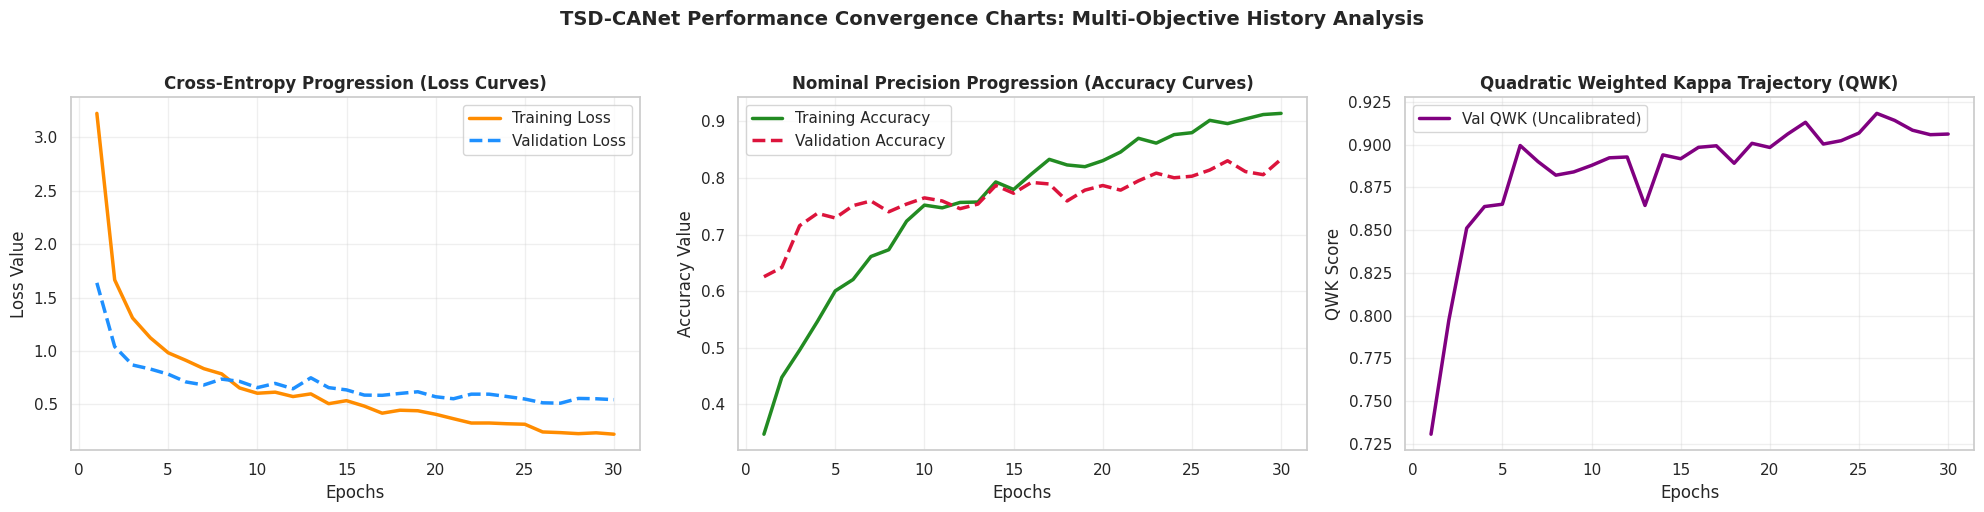

[SAVED] 'manuscript_figure_training_metrics_curves.png' exported at 300 DPI.


In [13]:
# SYSTEM STAGE 10: MANUSCRIPT VISUALIZATION - PROGRESSION CURVES CHART
# =========================================================================
completed_epochs_range = range(1, len(history_train_loss) + 1)
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# 1. Loss Curves Plot
ax[0].plot(completed_epochs_range, history_train_loss, label='Training Loss', color='darkorange', lw=2.5)
ax[0].plot(completed_epochs_range, history_val_loss, label='Validation Loss', color='dodgerblue', lw=2.5, linestyle='--')
ax[0].set_title('Cross-Entropy Progression (Loss Curves)', fontweight='bold')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss Value')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# 2. Accuracy Curves Plot
ax[1].plot(completed_epochs_range, history_train_acc, label='Training Accuracy', color='forestgreen', lw=2.5)
ax[1].plot(completed_epochs_range, history_val_acc, label='Validation Accuracy', color='crimson', lw=2.5, linestyle='--')
ax[1].set_title('Nominal Precision Progression (Accuracy Curves)', fontweight='bold')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy Value')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# 3. Validation QWK Curves Plot
ax[2].plot(completed_epochs_range, history_val_qwk, label='Val QWK (Uncalibrated)', color='purple', lw=2.5)
ax[2].set_title('Quadratic Weighted Kappa Trajectory (QWK)', fontweight='bold')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('QWK Score')
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.suptitle("TSD-CANet Performance Convergence Charts: Multi-Objective History Analysis", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("manuscript_figure_training_metrics_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print("[SAVED] 'manuscript_figure_training_metrics_curves.png' exported at 300 DPI.")

In [14]:
# SYSTEM STAGE 11 & 12: OPTIMAL WEIGHT RECOVERY & PURE TEST EVALUATION
# =========================================================================
print("\n--- RECOVERING PEAK VALIDATION ARCHITECTURE WEIGHTS ---")
checkpoint = torch.load("best_publication_model.pth", map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("\n--- RUNNING VANILLA EVALUATION ON UNSEEN TEST COHORT ---")
test_preds, test_labels, test_probs = [], [], []

with torch.no_grad():
    for images, _, labels, _ in tqdm(test_loader, desc="Testing Evaluation"):
        images = images.to(DEVICE, dtype=torch.float)
        logits = model(images)
        probas = torch.sigmoid(logits).cpu().numpy()
        
        # Map raw conditional outputs back to 5-class distribution array
        batch_size = logits.size(0)
        class_probs = np.zeros((batch_size, 5))
        class_probs[:, 0] = 1.0 - probas[:, 0]
        class_probs[:, 1] = probas[:, 0] * (1.0 - probas[:, 1])
        class_probs[:, 2] = probas[:, 0] * probas[:, 1] * (1.0 - probas[:, 2])
        class_probs[:, 3] = probas[:, 0] * probas[:, 1] * probas[:, 2] * (1.0 - probas[:, 3])
        class_probs[:, 4] = probas[:, 0] * probas[:, 1] * probas[:, 2] * probas[:, 3]
        
        # Decode classes using the strict vanilla 0.5 conditional boundary check
        preds = (torch.sigmoid(logits) > 0.5).sum(dim=1).cpu().numpy()

        test_preds.extend(preds)
        test_labels.extend(labels.numpy())
        test_probs.extend(class_probs)

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

# Compute final publication metrics matching baseline metrics
final_accuracy  = accuracy_score(test_labels, test_preds)
final_precision = precision_score(test_labels, test_preds, average="weighted")
final_recall    = recall_score(test_labels, test_preds, average="weighted")
final_f1        = f1_score(test_labels, test_preds, average="weighted")
final_qwk       = cohen_kappa_score(test_labels, test_preds, weights="quadratic")
final_macro_auc = roc_auc_score(test_labels, test_probs, multi_class="ovr", average="macro")

print("\n" + "="*60)
print("             TSD-CORN FINAL MANUSCRIPT METRIC MATRIX            ")
print("="*60)
print(f"Final Test Accuracy  : {final_accuracy:.4f}")
print(f"Final Test Precision : {final_precision:.4f}")
print(f"Final Test Recall    : {final_recall:.4f}")
print(f"Final Test F1 Score  : {final_f1:.4f}")
print(f"Final Test QWK Score : {final_qwk:.4f}")
print(f"Overall Macro AUC    : {final_macro_auc:.4f}")
print("="*60)

print("\n--- CORE PARSING DISCRETE SEVERITY CLASSIFICATION REPORT ---")
print(classification_report(test_labels, test_preds, digits=4, target_names=class_names_list))


--- RECOVERING PEAK VALIDATION ARCHITECTURE WEIGHTS ---

--- RUNNING VANILLA EVALUATION ON UNSEEN TEST COHORT ---


Testing Evaluation: 100%|██████████| 12/12 [00:14<00:00,  1.18s/it]


             TSD-CORN FINAL MANUSCRIPT METRIC MATRIX            
Final Test Accuracy  : 0.8333
Final Test Precision : 0.8525
Final Test Recall    : 0.8333
Final Test F1 Score  : 0.8339
Final Test QWK Score : 0.9133
Overall Macro AUC    : 0.9417

--- CORE PARSING DISCRETE SEVERITY CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

       Normal (0)     0.9949    0.9749    0.9848       199
         Mild (1)     0.5625    0.6000    0.5806        30
     Moderate (2)     0.6961    0.8161    0.7513        87
       Severe (3)     0.3333    0.4118    0.3684        17
Proliferative (4)     0.9375    0.4545    0.6122        33

         accuracy                         0.8333       366
        macro avg     0.7049    0.6515    0.6595       366
     weighted avg     0.8525    0.8333    0.8339       366



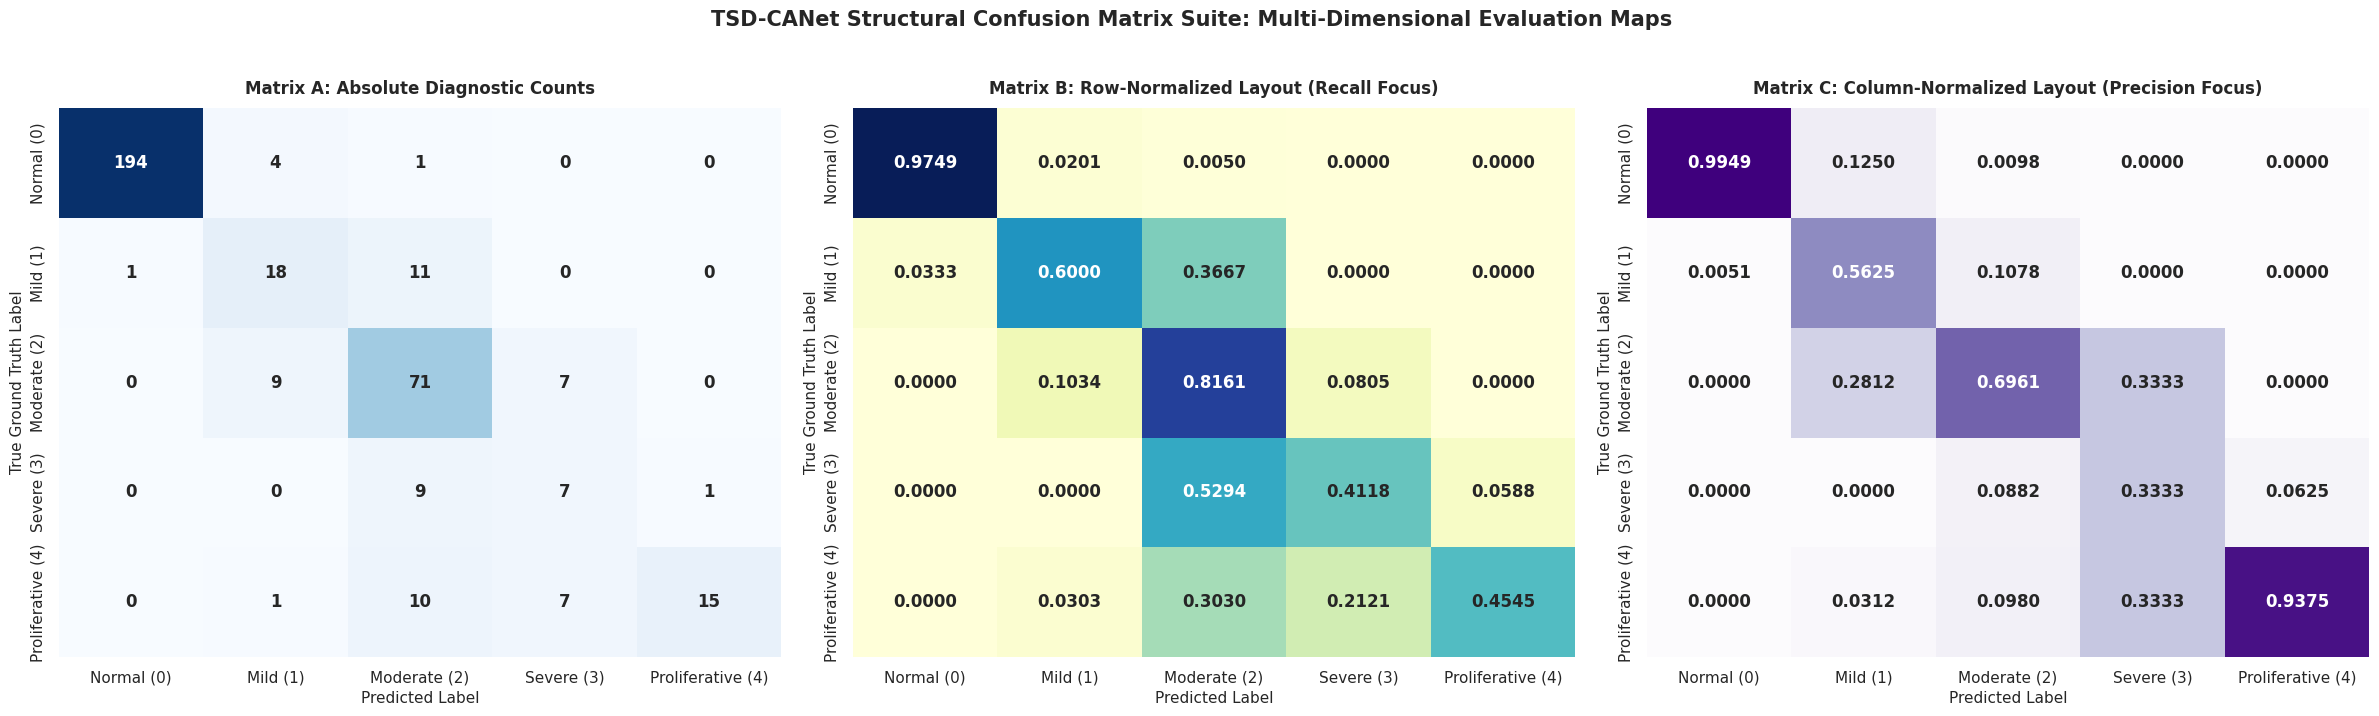

[SAVED] 'manuscript_figure_confusion_matrix_suite.png' exported at 300 DPI.


In [15]:
# SYSTEM STAGE 13: MANUSCRIPT VISUALIZATION - COMPREHENSIVE CONFUSION MATRICES
# =========================================================================
cm_absolute   = confusion_matrix(test_labels, test_preds)
cm_recall_norm   = confusion_matrix(test_labels, test_preds, normalize='true')   # Row-normalized
cm_precision_norm = confusion_matrix(test_labels, test_preds, normalize='pred')   # Column-normalized

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot A: Absolute Integer Counts
sns.heatmap(cm_absolute, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=class_names_list, yticklabels=class_names_list, cbar=False, annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title("Matrix A: Absolute Diagnostic Counts", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Ground Truth Label", fontsize=11)

# Plot B: Row-Normalized Matrix (Sensitivity / Recall Focus)
sns.heatmap(cm_recall_norm, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[1],
            xticklabels=class_names_list, yticklabels=class_names_list, cbar=False, annot_kws={"size": 12, "weight": "bold"})
axes[1].set_title("Matrix B: Row-Normalized Layout (Recall Focus)", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Ground Truth Label", fontsize=11)

# Plot C: Column-Normalized Matrix (Precision Focus)
sns.heatmap(cm_precision_norm, annot=True, fmt=".4f", cmap="Purples", ax=axes[2],
            xticklabels=class_names_list, yticklabels=class_names_list, cbar=False, annot_kws={"size": 12, "weight": "bold"})
axes[2].set_title("Matrix C: Column-Normalized Layout (Precision Focus)", fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel("Predicted Label", fontsize=11)
axes[2].set_ylabel("True Ground Truth Label", fontsize=11)

plt.suptitle("TSD-CANet Structural Confusion Matrix Suite: Multi-Dimensional Evaluation Maps", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("manuscript_figure_confusion_matrix_suite.png", dpi=300, bbox_inches='tight')
plt.show()
print("[SAVED] 'manuscript_figure_confusion_matrix_suite.png' exported at 300 DPI.")

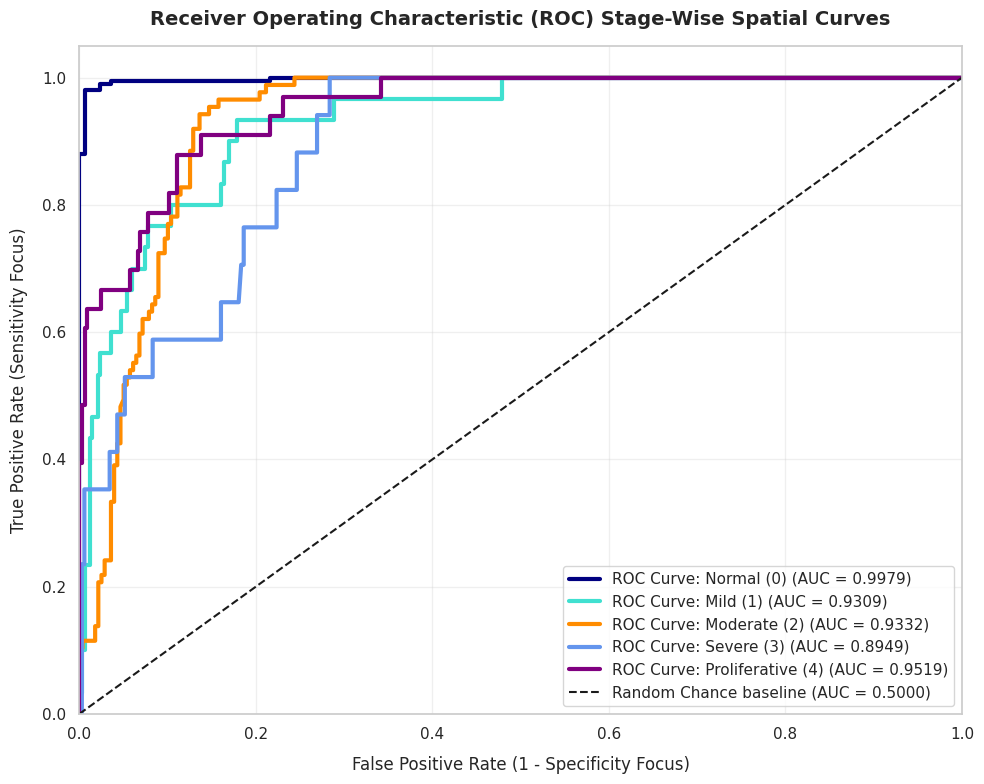

[SAVED] 'manuscript_figure_multiclass_roc_curves.png' exported at 300 DPI.

             EXECUTION COMPLETE: ALL PLOTS & CHARTS SAVED       


In [16]:
# SYSTEM STAGE 14: MANUSCRIPT VISUALIZATION - STAGE-WISE ROC CURVES
# =========================================================================
test_labels_binarized = label_binarize(test_labels, classes=[0, 1, 2, 3, 4])
fpr_registry, tpr_registry, roc_auc_registry = dict(), dict(), dict()
curve_colors = ['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'purple']

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr_registry[i], tpr_registry[i], _ = roc_curve(test_labels_binarized[:, i], test_probs[:, i])
    roc_auc_registry[i] = auc(fpr_registry[i], tpr_registry[i])
    plt.plot(fpr_registry[i], tpr_registry[i], color=curve_colors[i], lw=3.0,
             label=f'ROC Curve: {class_names_list[i]} (AUC = {roc_auc_registry[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance baseline (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity Focus)', fontsize=12, labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity Focus)', fontsize=12, labelpad=10)
plt.title('Receiver Operating Characteristic (ROC) Stage-Wise Spatial Curves', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("manuscript_figure_multiclass_roc_curves.png", dpi=300)
plt.show()
print("[SAVED] 'manuscript_figure_multiclass_roc_curves.png' exported at 300 DPI.\n")

print("="*60)
print("             EXECUTION COMPLETE: ALL PLOTS & CHARTS SAVED       ")
print("="*60)

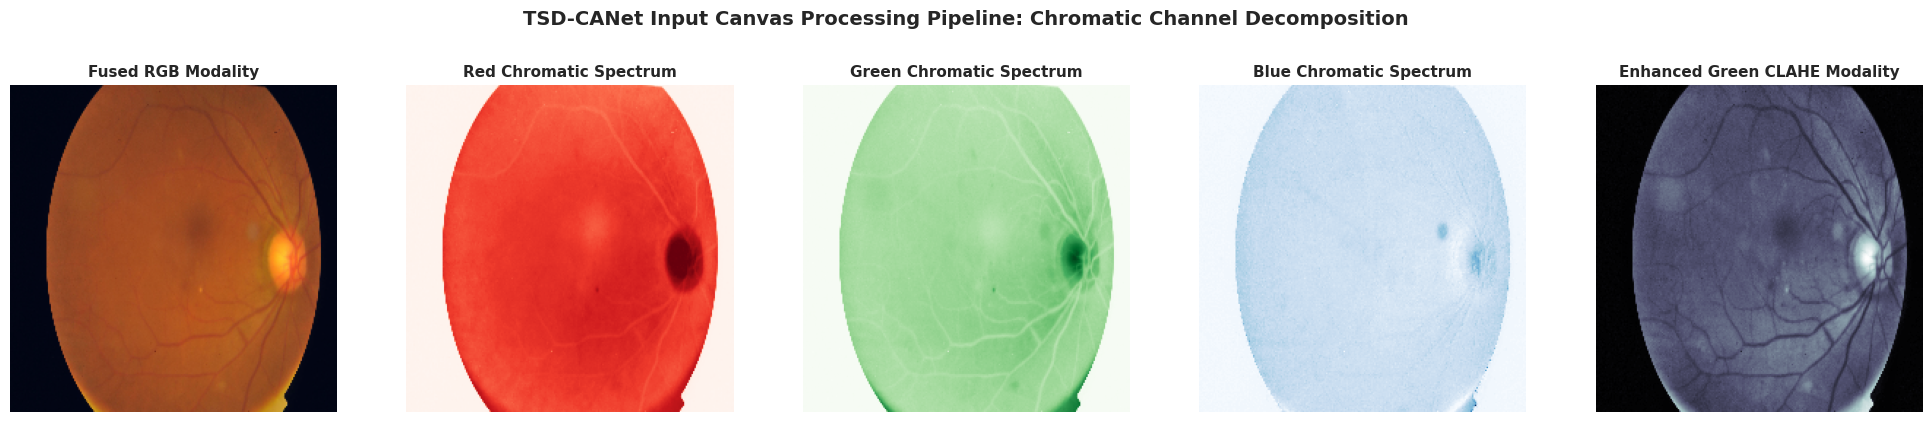

[SAVED] Color-coded 'manuscript_figure_color_spectral_breakdown.png' exported at 300 DPI.


In [24]:
# =========================================================================
# SYSTEM STAGE 4: MULTI-SPECTRAL CHROMATIC DECOMPOSITION (VAL DETERMINISTIC)
# =========================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Force deterministic image mapping by pulling directly from the validation pool
_, _, _, target_raw_sample = train_dataset[0]

# 1. Coordinate Axes Shape Alignment (C, H, W -> H, W, C)
if isinstance(target_raw_sample, torch.Tensor):
    img_np = target_raw_sample.permute(1, 2, 0).cpu().numpy()
else:
    img_np = target_raw_sample

# 2. Rescale Matrix Range to [0, 1] to prevent Matplotlib clipping bugs
img_min = img_np.min()
img_max = img_np.max()
img_safe = (img_np - img_min) / (img_max - img_min + 1e-8)

# 3. Flawless Multi-Spectral Chromatic Rendering
axes[0].imshow(img_safe[:, :, :3])
axes[0].set_title("Fused RGB Modality", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_safe[:, :, 0], cmap='Reds')
axes[1].set_title("Red Chromatic Spectrum", fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_safe[:, :, 1], cmap='Greens')
axes[2].set_title("Green Chromatic Spectrum", fontsize=11, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(img_safe[:, :, 2], cmap='Blues')
axes[3].set_title("Blue Chromatic Spectrum", fontsize=11, fontweight='bold')
axes[3].axis('off')

axes[4].imshow(img_safe[:, :, 3], cmap='bone')
axes[4].set_title("Enhanced Green CLAHE Modality", fontsize=11, fontweight='bold')
axes[4].axis('off')

plt.suptitle("TSD-CANet Input Canvas Processing Pipeline: Chromatic Channel Decomposition", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("manuscript_figure_color_spectral_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()
print("[SAVED] Color-coded 'manuscript_figure_color_spectral_breakdown.png' exported at 300 DPI.")

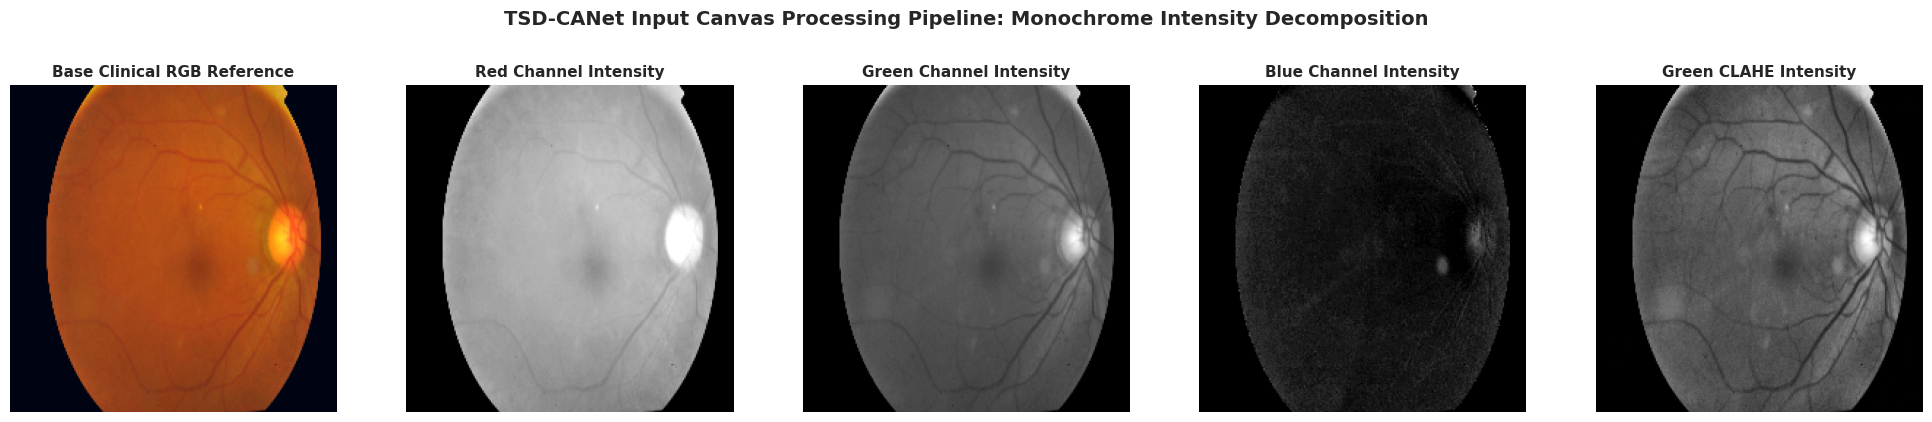

[SAVED] Monochrome 'manuscript_figure_grayscale_intensity_breakdown.png' exported at 300 DPI.


In [23]:
# =========================================================================
# SYSTEM STAGE 4: MONOCHROME INTENSITY DECOMPOSITION (VAL DETERMINISTIC)
# =========================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Pull the exact same image instance from the validation pool to guarantee consistency
_, _, _, target_raw_sample = train_dataset[0]

# 1. Coordinate Axes Shape Alignment (C, H, W -> H, W, C)
if isinstance(target_raw_sample, torch.Tensor):
    img_np = target_raw_sample.permute(1, 2, 0).cpu().numpy()
else:
    img_np = target_raw_sample

# 2. Rescale Matrix Range to [0, 1] to prevent Matplotlib clipping bugs
img_min = img_np.min()
img_max = img_np.max()
img_safe = (img_np - img_min) / (img_max - img_min + 1e-8)

# 3. Flawless Grayscale Intensity Rendering
axes[0].imshow(img_safe[:, :, :3]) # Retained in full color as a reference baseline
axes[0].set_title("Base Clinical RGB Reference", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_safe[:, :, 0], cmap='gray') 
axes[1].set_title("Red Channel Intensity", fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_safe[:, :, 1], cmap='gray') 
axes[2].set_title("Green Channel Intensity", fontsize=11, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(img_safe[:, :, 2], cmap='gray') 
axes[3].set_title("Blue Channel Intensity", fontsize=11, fontweight='bold')
axes[3].axis('off')

axes[4].imshow(img_safe[:, :, 3], cmap='gray') 
axes[4].set_title("Green CLAHE Intensity", fontsize=11, fontweight='bold')
axes[4].axis('off')

plt.suptitle("TSD-CANet Input Canvas Processing Pipeline: Monochrome Intensity Decomposition", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("manuscript_figure_grayscale_intensity_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()
print("[SAVED] Monochrome 'manuscript_figure_grayscale_intensity_breakdown.png' exported at 300 DPI.")